<a href="https://colab.research.google.com/github/ya1em2arbuzik/Andoskin3VARIANT/blob/master/RABOTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

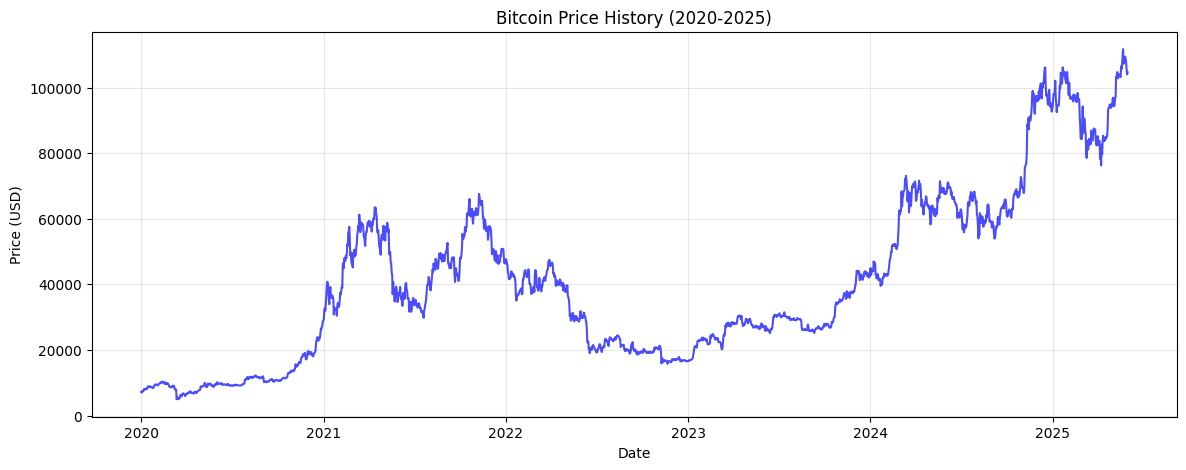

Train: (1534, 60, 1), Val: (191, 60, 1), Test: (193, 60, 1)
Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 0.0083 - mae: 0.0571 - val_loss: 0.0024 - val_mae: 0.0388
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 8.5548e-04 - mae: 0.0198 - val_loss: 0.0017 - val_mae: 0.0322
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 7.0711e-04 - mae: 0.0180 - val_loss: 0.0015 - val_mae: 0.0295
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 6.2529e-04 - mae: 0.0171 - val_loss: 0.0014 - val_mae: 0.0290
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 6.1061e-04 - mae: 0.0169 - val_loss: 0.0013 - val_mae: 0.0276
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 5.7670e-04 - mae: 0.0164 - val_loss: 0.0013 - val_mae: 0.0268
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 5.5852e-04 - mae: 0.0162 - val_loss: 0.0012 - val_mae: 0.0260
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 5.3676e-04 - mae: 0.0159 - va

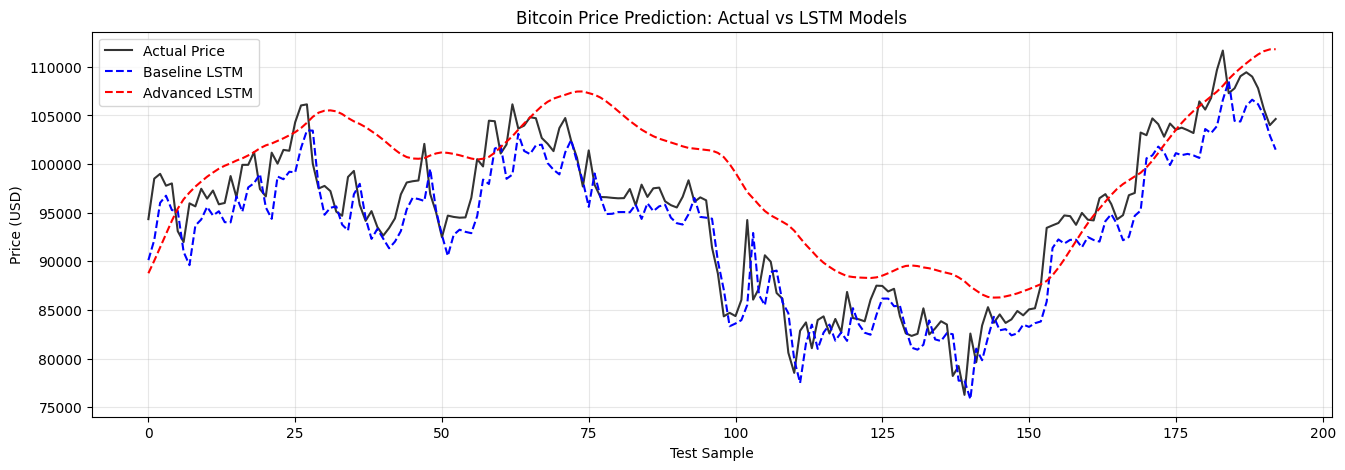

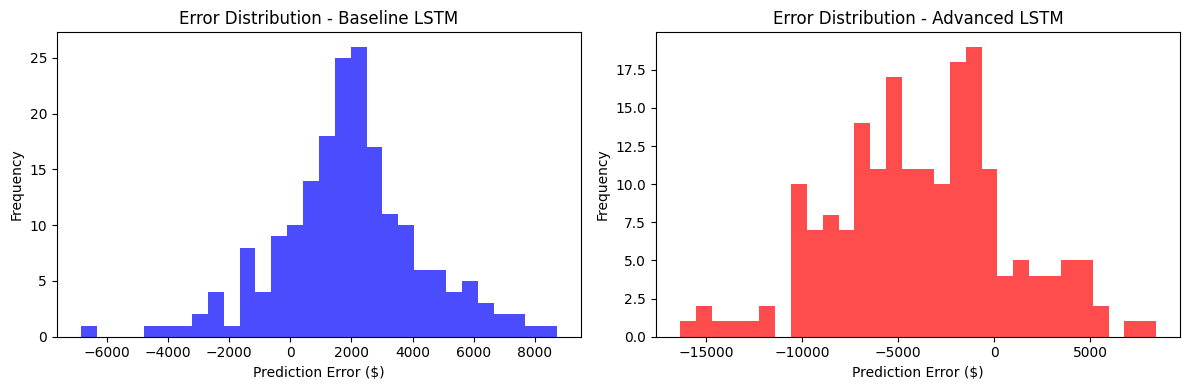

In [ ]:
# Bitcoin Price Prediction with LSTM
# ============================================================
# Установка библиотек и импорт
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# Фиксация random_seed для воспроизводимости
def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
set_seed(42)

# Загрузка данных с Yahoo Finance
!pip install yfinance -q
import yfinance as yf

btc = yf.download('BTC-USD', start='2020-01-01', end='2025-06-01', progress=False)
df = btc[['Close']].copy()
df.head()

# ============================================================
# Визуализация данных
# ============================================================
plt.figure(figsize=(14,5))
plt.plot(df['Close'], color='blue', alpha=0.7)
plt.title('Bitcoin Price History (2020-2025)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Подготовка данных для LSTM
# ============================================================
# Нормализация
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)

# Создание окон для последовательного обучения (look_back = 60 дней)
def create_sequences(data, look_back=60):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

look_back = 60
X, y = create_sequences(scaled_data, look_back)

# Разбиение на train/validation/test (80/10/10)
train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.1)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

# Изменение формы для LSTM (samples, time_steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# ============================================================
# Построение и обучение моделей
# ============================================================
# Базовый LSTM
model_baseline = Sequential([
    LSTM(50, return_sequences=True, input_shape=(look_back, 1)),
    LSTM(50),
    Dense(1)
])
model_baseline.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_baseline = model_baseline.fit(
    X_train, y_train,
    epochs=100, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# Усложнённый LSTM
model_advanced = Sequential([
    LSTM(128, return_sequences=True, input_shape=(look_back, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])
model_advanced.compile(optimizer='adam', loss='mse', metrics=['mae'])
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

history_advanced = model_advanced.fit(
    X_train, y_train,
    epochs=100, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ============================================================
# Оценка моделей и метрики
# ============================================================
def evaluate_model(model, X_test, y_test, scaler, name='Model'):
    predictions = model.predict(X_test, verbose=0)
    predictions_inv = scaler.inverse_transform(predictions.reshape(-1,1))
    actual_inv = scaler.inverse_transform(y_test.reshape(-1,1))

    mse = mean_squared_error(actual_inv, predictions_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual_inv, predictions_inv)
    r2 = r2_score(actual_inv, predictions_inv)

    print(f"\n{name} Results:")
    print(f"  MSE:  {mse:.2f}")
    print(f"  RMSE: ${rmse:.2f}")
    print(f"  MAE:  ${mae:.2f}")
    print(f"  R²:   {r2:.4f}")
    return actual_inv, predictions_inv, rmse

actual, pred_baseline, rmse_baseline = evaluate_model(model_baseline, X_test, y_test, scaler, 'Baseline LSTM')
actual, pred_advanced, rmse_advanced = evaluate_model(model_advanced, X_test, y_test, scaler, 'Advanced LSTM')

# ============================================================
# Визуализация результатов
# ============================================================
plt.figure(figsize=(16,5))
plt.plot(actual, label='Actual Price', color='black', alpha=0.8)
plt.plot(pred_baseline, label='Baseline LSTM', linestyle='--', color='blue')
plt.plot(pred_advanced, label='Advanced LSTM', linestyle='--', color='red')
plt.title('Bitcoin Price Prediction: Actual vs LSTM Models')
plt.xlabel('Test Sample')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Анализ распределения остатков
errors_baseline = actual.flatten() - pred_baseline.flatten()
errors_advanced = actual.flatten() - pred_advanced.flatten()

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(errors_baseline, bins=30, alpha=0.7, color='blue')
plt.title('Error Distribution - Baseline LSTM')
plt.xlabel('Prediction Error ($)')
plt.ylabel('Frequency')
plt.subplot(1,2,2)
plt.hist(errors_advanced, bins=30, alpha=0.7, color='red')
plt.title('Error Distribution - Advanced LSTM')
plt.xlabel('Prediction Error ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()